# Tech Challenge — Predição de Risco de Câncer de Colo do Útero

## Pós-graduação em IA para Devs

# Introdução

O câncer de colo do útero representa um importante problema de saúde pública, especialmente em países em desenvolvimento, sendo uma das principais causas de mortalidade feminina relacionada ao câncer. A doença possui forte associação com a infecção persistente pelo Papilomavírus Humano (HPV), além de outros fatores de risco comportamentais, clínicos e socioeconômicos.

Apesar dos avanços nos programas de prevenção e rastreamento, muitas mulheres ainda recebem o diagnóstico em estágios avançados, o que reduz significativamente as chances de tratamento eficaz e aumenta os impactos físicos, emocionais e sociais causados pela doença. Nesse contexto, o uso de técnicas de análise de dados e Inteligência Artificial pode contribuir como ferramenta de apoio à identificação precoce de fatores associados ao risco da doença.

Este projeto tem como objetivo aplicar técnicas de Machine Learning para análise e predição de risco relacionado ao câncer de colo do útero, utilizando o dataset “Cervical Cancer (Risk Factors)” disponibilizado no Kaggle. A proposta envolve desde a análise exploratória dos dados até a construção e avaliação de modelos de classificação supervisionada.

Durante o desenvolvimento do projeto serão realizadas etapas de tratamento de dados, análise exploratória baseada em hipóteses e perguntas analíticas, criação de visualizações gráficas, treinamento de modelos preditivos e interpretação dos resultados obtidos. Além disso, serão utilizadas técnicas de explicabilidade, como Feature Importance e SHAP, visando aumentar a transparência das previsões realizadas pelos modelos.

O projeto também busca discutir a importância da aplicação de Inteligência Artificial na área da saúde, especialmente como ferramenta de apoio à tomada de decisão médica, sem substituir a avaliação realizada por profissionais especializados. Dessa forma, pretende-se demonstrar como a análise de dados pode auxiliar na identificação de padrões relevantes e contribuir para estratégias de prevenção e diagnóstico precoce.

# Objetivos

## Objetivo Geral

Desenvolver dois modelos de Machine Learning capazes de auxiliar na predição de risco relacionado ao câncer de colo do útero.

## Objetivos Específicos

- Realizar análise exploratória dos dados
- Investigar possíveis fatores de risco
- Tratar dados ausentes
- Construir modelos de classificação
- Comparar desempenho entre modelos
- Aplicar técnicas de explicabilidade
- Discutir aplicações de IA na saúde

# Importação das Bibliotecas

Inicialmente, importei as bibliotecas que seriam utilizadas ao longo da análise. O pandas e o numpy foram usados para manipulação dos dados, enquanto matplotlib e seaborn auxiliaram na criação dos gráficos. Também utilizei módulos do scikit-learn para o pré-processamento e treinamento dos modelos, além da biblioteca shap para ajudar na interpretação e explicação dos resultados obtidos.

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score
)

import shap

# Carregamento e Exploração do Dataset

Primeiro, realizei o carregamento do dataset de câncer cervical a partir do arquivo CSV. Após isso, visualizei as primeiras linhas da base com head() para ter uma visão inicial dos dados e entender como as informações estavam organizadas. Também utilizei tail() para observar os últimos registros do dataset e verificar se os dados mantinham o mesmo padrão ao longo da base.

Em seguida, utilizei df.shape para verificar a quantidade de linhas e colunas presentes no dataset, permitindo compreender o tamanho da base de dados. Depois, apliquei info() para analisar os tipos das variáveis e identificar possíveis valores ausentes. Além disso, utilizei describe() para obter um resumo estatístico das variáveis numéricas, facilitando a compreensão da distribuição dos dados.

Também utilizei isnull().sum() para verificar a quantidade de valores nulos existentes em cada coluna, auxiliando na definição das etapas de tratamento dos dados. Por fim, analisei a variável alvo Biopsy utilizando value_counts() para verificar a quantidade de casos em cada classe e value_counts(normalize=True) para observar a proporção entre os resultados, permitindo entender melhor o balanceamento do dataset antes da modelagem.


#### Visualização inicial

In [2]:
# carregando dataset

df = pd.read_csv('../data/cervical-cancer_csv.csv')

# primeiras linhas

df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


#### Últimas linhas

In [3]:
df.tail()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
830,34,3.0,18.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
831,32,2.0,19.0,1.0,0.0,0.0,0.0,1.0,8.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
832,25,2.0,17.0,0.0,0.0,0.0,0.0,1.0,0.08,0.0,...,NaN,NaN,0,0,0,0,0,0,1,0
833,33,2.0,24.0,2.0,0.0,0.0,0.0,1.0,0.08,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
834,29,2.0,20.0,1.0,0.0,0.0,0.0,1.0,0.50,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


#### Informações gerais

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 835 non-null    int64  
 1   Number of sexual partners           810 non-null    float64
 2   First sexual intercourse            828 non-null    float64
 3   Num of pregnancies                  779 non-null    float64
 4   Smokes                              822 non-null    float64
 5   Smokes (years)                      822 non-null    float64
 6   Smokes (packs/year)                 822 non-null    float64
 7   Hormonal Contraceptives             732 non-null    float64
 8   Hormonal Contraceptives (years)     732 non-null    float64
 9   IUD                                 723 non-null    float64
 10  IUD (years)                         723 non-null    float64
 11  STDs                                735 non-n

#### Quantidade de linhas e colunas

In [5]:
df.shape

(835, 36)

#### Estatísticas descritivas 

In [6]:
df.describe()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
count,835.000000,810.000000,828.000000,779.000000,822.000000,822.000000,822.000000,732.000000,732.000000,723.000000,...,71.000000,71.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000
mean,27.023952,2.551852,17.020531,2.304236,0.149635,1.253850,0.465823,0.651639,2.302916,0.114799,...,6.140845,5.816901,0.021557,0.010778,0.021557,0.028743,0.041916,0.087425,0.051497,0.064671
std,8.482986,1.676686,2.817000,1.455817,0.356930,4.140727,2.256273,0.476777,3.794180,0.319000,...,5.895024,5.755271,0.145319,0.103320,0.145319,0.167182,0.200518,0.282626,0.221142,0.246091
min,13.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.000000,2.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,2.000000,17.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.500000,0.000000,...,4.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,3.000000,18.000000,3.000000,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,...,8.000000,7.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,84.000000,28.000000,32.000000,11.000000,1.000000,37.000000,37.000000,1.000000,30.000000,1.000000,...,22.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Verificando valores únicos da variável target

A variável “Biopsy” foi escolhida como target do projeto por representar o resultado da biópsia realizada nas pacientes, indicando presença ou ausência de diagnóstico relacionado ao câncer cervical.

Como o objetivo do projeto é desenvolver modelos capazes de auxiliar na predição de risco da doença, essa variável se mostrou a mais adequada para treinamento dos algoritmos de classificação supervisionada.

In [7]:
df['Biopsy'].value_counts()

Biopsy
0    781
1     54
Name: count, dtype: int64

#### Proporção da variável target

In [8]:
df['Biopsy'].value_counts(normalize=True)

Biopsy
0    0.935329
1    0.064671
Name: proportion, dtype: float64

#### Valores ausentes

In [9]:
df.isnull().sum()

Age                                     0
Number of sexual partners              25
First sexual intercourse                7
Num of pregnancies                     56
Smokes                                 13
Smokes (years)                         13
Smokes (packs/year)                    13
Hormonal Contraceptives               103
Hormonal Contraceptives (years)       103
IUD                                   112
IUD (years)                           112
STDs                                  100
STDs (number)                         100
STDs:condylomatosis                   100
STDs:cervical condylomatosis          100
STDs:vaginal condylomatosis           100
STDs:vulvo-perineal condylomatosis    100
STDs:syphilis                         100
STDs:pelvic inflammatory disease      100
STDs:genital herpes                   100
STDs:molluscum contagiosum            100
STDs:AIDS                             100
STDs:HIV                              100
STDs:Hepatitis B                  

## Discussão

O dataset utilizado contém informações clínicas e comportamentais relacionadas aos fatores de risco associados ao câncer cervical, essas informações podem contribuir para identificação de padrões associados ao risco de câncer cervical. Durante a análise inicial da base, foi possível identificar a presença de valores ausentes em algumas variáveis. Dessa forma, será necessário realizar um tratamento adequado desses dados antes da etapa de modelagem, garantindo maior qualidade e confiabilidade nos resultados obtidos.

# Limpeza de Dados e Tratamento de Valores Ausentes

Nesta etapa, realizei a conversão das colunas do dataset para valores numéricos utilizando pd.to_numeric(), garantindo que os dados ficassem no formato adequado para as análises e para o treinamento dos modelos. Durante esse processo, possíveis valores incompatíveis foram convertidos automaticamente em valores ausentes. Em seguida, utilizei o SimpleImputer com estratégia de mediana para preencher esses valores faltantes, buscando manter maior equilíbrio nos dados. Por fim, conferi novamente a base utilizando isnull().sum() para verificar se ainda existiam valores ausentes após o tratamento.

#### Percentual de valores ausentes

In [10]:
(df.isnull().sum() / len(df)) * 100

Age                                    0.000000
Number of sexual partners              2.994012
First sexual intercourse               0.838323
Num of pregnancies                     6.706587
Smokes                                 1.556886
Smokes (years)                         1.556886
Smokes (packs/year)                    1.556886
Hormonal Contraceptives               12.335329
Hormonal Contraceptives (years)       12.335329
IUD                                   13.413174
IUD (years)                           13.413174
STDs                                  11.976048
STDs (number)                         11.976048
STDs:condylomatosis                   11.976048
STDs:cervical condylomatosis          11.976048
STDs:vaginal condylomatosis           11.976048
STDs:vulvo-perineal condylomatosis    11.976048
STDs:syphilis                         11.976048
STDs:pelvic inflammatory disease      11.976048
STDs:genital herpes                   11.976048
STDs:molluscum contagiosum            11

#### Visualização gráfica dos valores ausentes

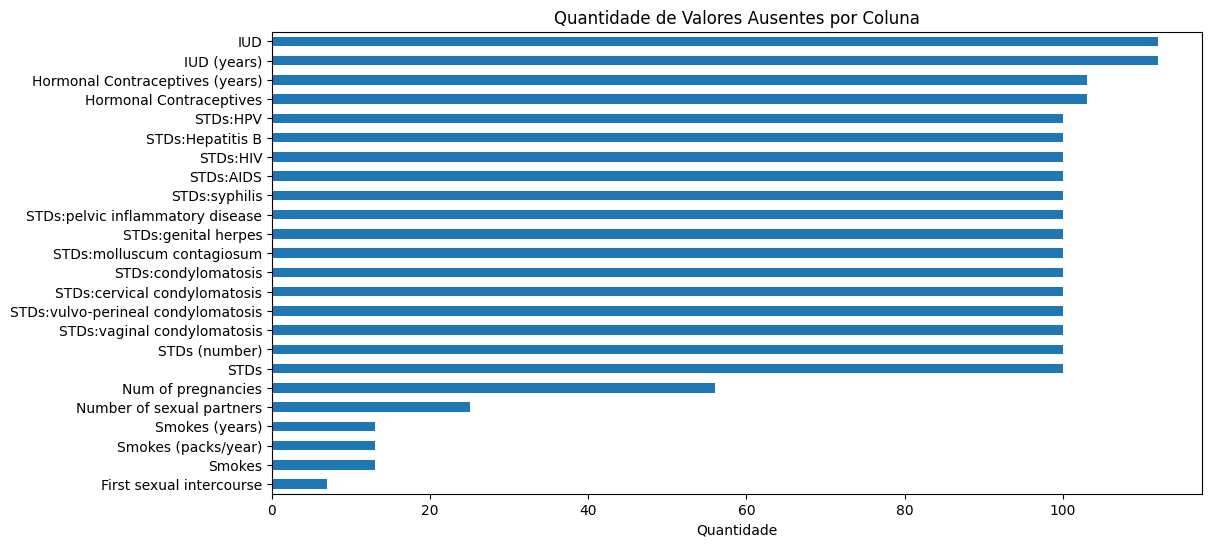

In [56]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(12,6))

missing_values.sort_values().plot(kind='barh')

plt.title('Quantidade de Valores Ausentes por Coluna')

plt.savefig('../images/valores-ausentes-por-coluna.png', bbox_inches='tight')

plt.xlabel('Quantidade')

plt.show()

#### Verificando registros duplicados

In [12]:
df.duplicated().sum()

np.int64(0)

#### Convertendo colunas para valores numéricos

In [13]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

#### Remoção de colunas
Durante a análise dos valores ausentes, observei que as colunas “STDs: Time since first diagnosis” e “STDs: Time since last diagnosis” apresentavam mais de 90% de dados nulos.
Devido à grande quantidade de informações faltantes, optei por remover essas variáveis em vez de realizar a imputação dos valores. Essa decisão foi tomada para evitar a inserção excessiva de dados artificiais no dataset, o que poderia influenciar negativamente as análises e comprometer o desempenho dos modelos preditivos.

In [14]:
colunas_remover = [
    'STDs: Time since first diagnosis',
    'STDs: Time since last diagnosis'
]

df = df.drop(columns=colunas_remover)

#### Aplicando imputação pela mediana

In [15]:
imputer = SimpleImputer(strategy='median')

df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

#### Conferindo valores ausentes

In [16]:
df_imputed.isnull().sum()

Age                                   0
Number of sexual partners             0
First sexual intercourse              0
Num of pregnancies                    0
Smokes                                0
Smokes (years)                        0
Smokes (packs/year)                   0
Hormonal Contraceptives               0
Hormonal Contraceptives (years)       0
IUD                                   0
IUD (years)                           0
STDs                                  0
STDs (number)                         0
STDs:condylomatosis                   0
STDs:cervical condylomatosis          0
STDs:vaginal condylomatosis           0
STDs:vulvo-perineal condylomatosis    0
STDs:syphilis                         0
STDs:pelvic inflammatory disease      0
STDs:genital herpes                   0
STDs:molluscum contagiosum            0
STDs:AIDS                             0
STDs:HIV                              0
STDs:Hepatitis B                      0
STDs:HPV                              0


## Discussão

A presença de valores ausentes é algo bastante comum em bases de dados da área da saúde, principalmente em pesquisas clínicas e sistemas médicos. Durante o tratamento dos dados, utilizei a imputação pela mediana para preencher os valores faltantes, já que essa estratégia costuma funcionar bem por sofrer menos influência de valores muito altos ou muito baixos.

Além disso, também realizei a verificação de registros duplicados e a conversão das variáveis para o formato numérico. Essas etapas foram importantes para deixar a base de dados mais organizada e compatível com os algoritmos de Machine Learning que serão utilizados nas próximas fases do projeto.

# Análise Exploratória de Dados (EDA)

A análise exploratória de dados tem como objetivo investigar padrões, tendências e possíveis relações entre as variáveis do dataset. Além de compreender melhor os dados, essa etapa auxilia na formulação de hipóteses analíticas e contribui para decisões relacionadas à modelagem preditiva.

Nesta análise serão investigadas possíveis relações entre: idade, tabagismo, histórico de DSTs, número de parceiros sexuais, uso de anticoncepcionais e diagnósticos positivos.

#### Pergunta 1 — Como está distribuída a variável target?

Ao analisar a variável de diagnóstico, foi possível observar uma quantidade maior de casos negativos em comparação aos positivos. Isso mostra que o dataset possui um desbalanceamento entre as classes, algo bastante comum em problemas da área médica. Esse tipo de comportamento pode influenciar o desempenho dos modelos preditivos, já que o algoritmo pode acabar aprendendo mais sobre a classe com maior quantidade de registros.

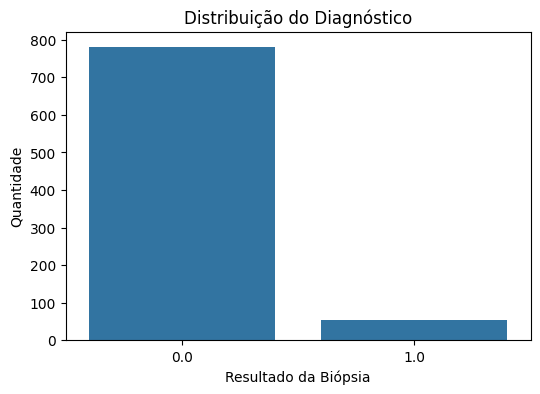

In [57]:
plt.figure(figsize=(6,4))

sns.countplot(x='Biopsy', data=df_imputed)

plt.title('Distribuição do Diagnóstico')

plt.savefig('../images/distribuicao-do-diagnostico.png', bbox_inches='tight')

plt.xlabel('Resultado da Biópsia')
plt.ylabel('Quantidade')

plt.show()

#### Pergunta 2 — Como a idade está distribuída entre as pacientes?

A análise da distribuição da idade mostrou uma maior concentração de pacientes em determinadas faixas etárias. O gráfico também ajudou a identificar a presença de possíveis valores extremos e a entender como os dados estão distribuídos ao longo da base.
O histograma mostra que a base de pacientes é predominantemente jovem, com um pico de frequência entre os 20 e 30 anos, e uma redução gradual conforme a idade aumenta.
Compreender essa distribuição é importante, pois a idade pode estar relacionada ao aumento do risco de algumas doenças, incluindo o câncer cervical.

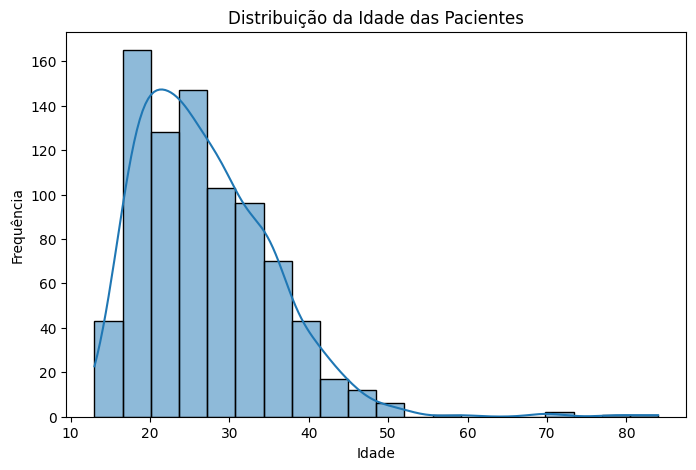

In [58]:
plt.figure(figsize=(8,5))

sns.histplot(df_imputed['Age'], bins=20, kde=True)

plt.title('Distribuição da Idade das Pacientes')

plt.savefig('../images/distribuicao-da-idade-dos-pacientes.png', bbox_inches='tight')

plt.xlabel('Idade')
plt.ylabel('Frequência')

plt.show()

#### Pergunta 3 — Pacientes com diagnóstico positivo tendem a ser mais velhas?

O boxplot foi utilizado para comparar a distribuição das idades entre pacientes com resultado positivo e negativo. Por meio da visualização, é possível observar se as pacientes diagnosticadas positivamente tendem a apresentar uma faixa etária diferente em relação às demais.
O gráfico indica que a mediana de idade das pacientes com diagnóstico positivo (1.0) é ligeiramente superior à das pacientes com resultado negativo (0.0), sugerindo que o risco pode aumentar sutilmente com a idade.
Além disso, o gráfico também auxilia na identificação de possíveis valores extremos e permite analisar a dispersão dos dados entre os grupos.

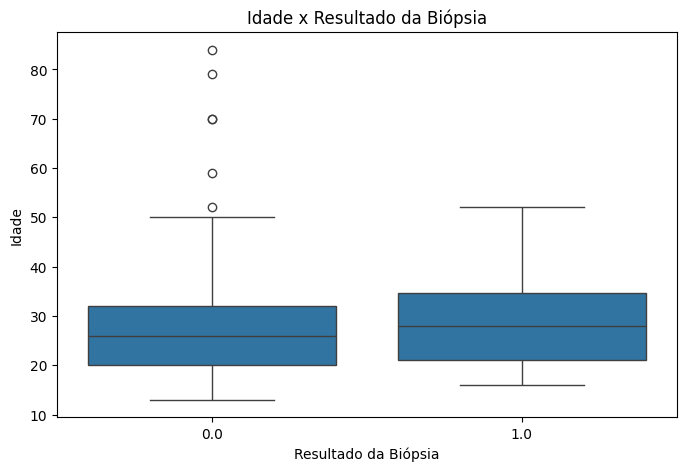

In [59]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Biopsy',
    y='Age',
    data=df_imputed
)

plt.title('Idade x Resultado da Biópsia')

plt.savefig('../images/resultado-da-biopsia.png', bbox_inches='tight')

plt.xlabel('Resultado da Biópsia')
plt.ylabel('Idade')

plt.show()

#### Pergunta 4 — Existe relação entre tabagismo e diagnóstico?

O tabagismo é um fator frequentemente associado ao aumento de riscos para diversas doenças. Neste gráfico, o objetivo foi analisar se pacientes com diagnóstico positivo apresentam um histórico maior de tabagismo em comparação às demais.
O gráfico de dispersão dentro do boxplot para anos de tabagismo mostra muitos valores discrepantes (outliers) em ambos os grupos, indicando que, embora alguns casos positivos tenham muitos anos de fumo, a maioria das pacientes não fuma.
Embora o gráfico não permita concluir uma relação de causa e efeito, ele ajuda a identificar possíveis tendências e diferenças entre os grupos analisados.

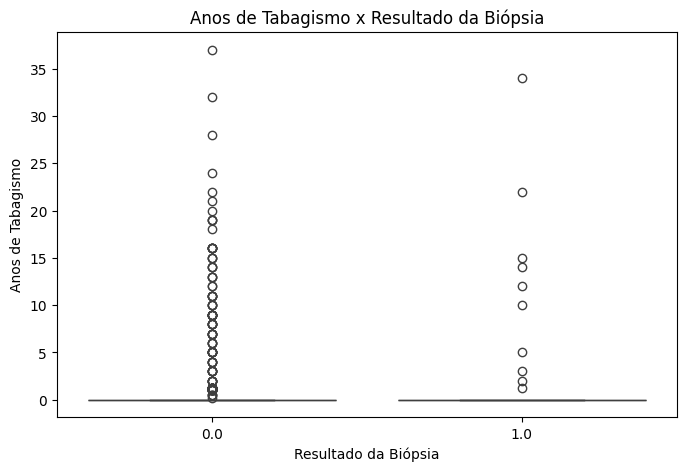

In [60]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Biopsy',
    y='Smokes (years)',
    data=df_imputed
)

plt.title('Anos de Tabagismo x Resultado da Biópsia')

plt.savefig('../images/tabagismo-versus-biopsia.png', bbox_inches='tight')

plt.xlabel('Resultado da Biópsia')
plt.ylabel('Anos de Tabagismo')

plt.show()

#### Pergunta 5 — Existe relação entre quantidade de parceiros sexuais e diagnóstico?

O violinplot permite visualizar não apenas os valores centrais, mas também a distribuição dos dados em cada grupo. Ele nos mostra distribuições muito semelhantes entre os dois grupos, com a maioria das pacientes tendo entre 1 e 5 parceiros, embora o grupo negativo apresente um valor extremo (outlier) muito acima da média.

Essa análise ajuda a investigar se pacientes com diagnóstico positivo apresentam tendência a possuir maior número de parceiros sexuais, fator frequentemente citado em estudos relacionados ao HPV e câncer cervical.

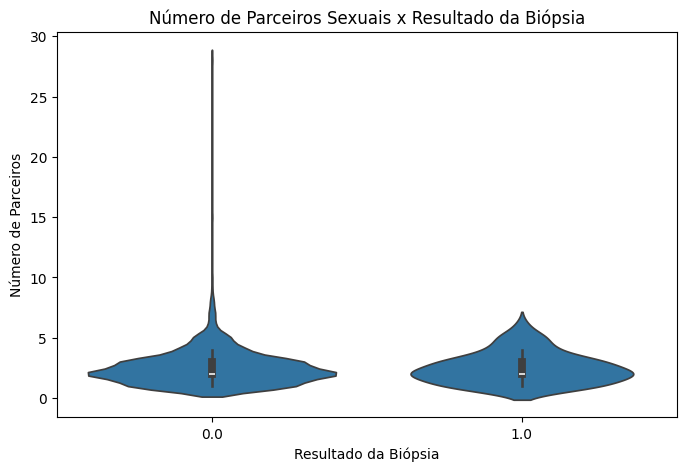

In [61]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='Biopsy',
    y='Number of sexual partners',
    data=df_imputed
)

plt.title('Número de Parceiros Sexuais x Resultado da Biópsia')

plt.savefig('../images/parceiros-sexuais-versus-biopsia.png', bbox_inches='tight')

plt.xlabel('Resultado da Biópsia')
plt.ylabel('Número de Parceiros')

plt.show()

#### Pergunta 6 — Uso prolongado de anticoncepcionais parece ter relação com o diagnóstico?

O objetivo desta análise foi verificar se existe alguma diferença no tempo de uso de anticoncepcionais hormonais entre pacientes com diagnóstico positivo e negativo. O boxplot revela que as pacientes com diagnóstico positivo têm uma mediana de anos de uso de anticoncepcionais levemente superior e uma dispersão maior no terceiro quartil em comparação ao grupo negativo.
Mesmo que essa visualização, sozinha, não permita chegar a conclusões definitivas, ela pode ajudar a identificar padrões e comportamentos relevantes que merecem uma análise mais aprofundada.

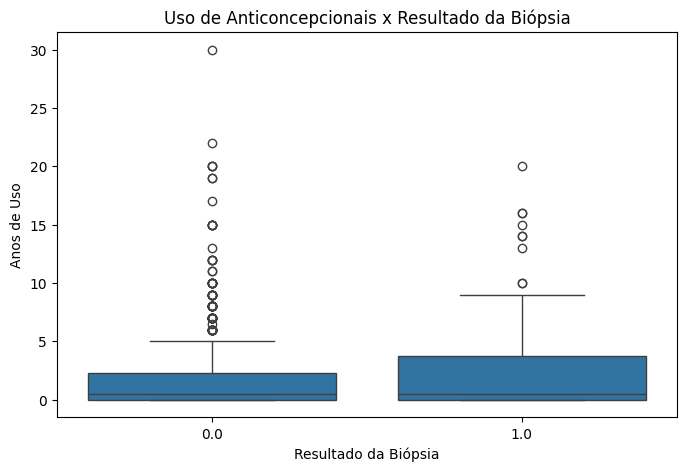

In [62]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Biopsy',
    y='Hormonal Contraceptives (years)',
    data=df_imputed
)

plt.title('Uso de Anticoncepcionais x Resultado da Biópsia')

plt.savefig('../images/anticoncepcionais-diagnostico.png', bbox_inches='tight')

plt.xlabel('Resultado da Biópsia')
plt.ylabel('Anos de Uso')

plt.show()

#### Pergunta 7 — Existe relação entre idade e número de parceiros sexuais?

O gráfico de dispersão foi utilizado para analisar possíveis relações entre a idade, o número de parceiros sexuais e o resultado da biópsia, nos mostrando que os casos positivos (laranja) estão espalhados, mas há uma leve concentração em pacientes entre 25 e 50 anos com menos de 10 parceiros.
A partir da visualização, também é possível observar se os casos positivos tendem a ficar mais concentrados em determinadas regiões do gráfico, o que pode indicar padrões importantes nos dados.

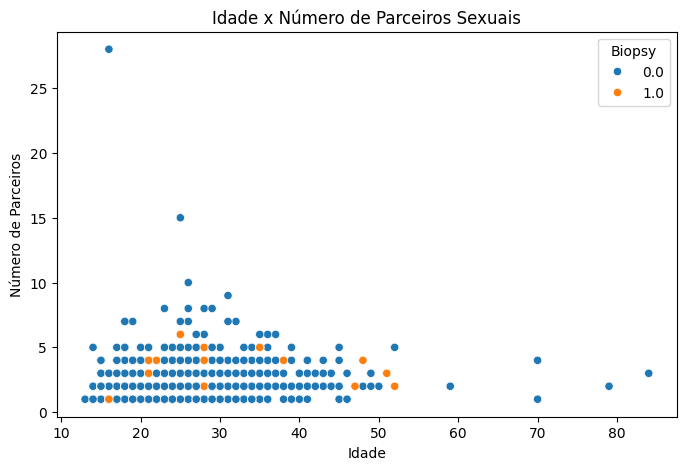

In [63]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Age',
    y='Number of sexual partners',
    hue='Biopsy',
    data=df_imputed
)

plt.title('Idade x Número de Parceiros Sexuais')

plt.savefig('../images/idade-versus-parceiros-sexuais.png', bbox_inches='tight')

plt.xlabel('Idade')
plt.ylabel('Número de Parceiros')

plt.show()

#### Pergunta 8 — Quais variáveis possuem maior correlação?

O mapa de correlação permite visualizar relações entre as variáveis do dataset.
Correlação positiva indica que duas variáveis tendem a aumentar juntas, enquanto correlação negativa indica comportamento oposto. O heatmap destaca fortes correlações positivas entre variáveis relacionadas (como "Dx: Cancer" e "Dx: HPV") e correlações mais fracas da variável "Biopsy" com as demais.
Apesar de correlação não significar causalidade, essa análise ajuda a identificar relações interessantes que podem influenciar os modelos preditivos.

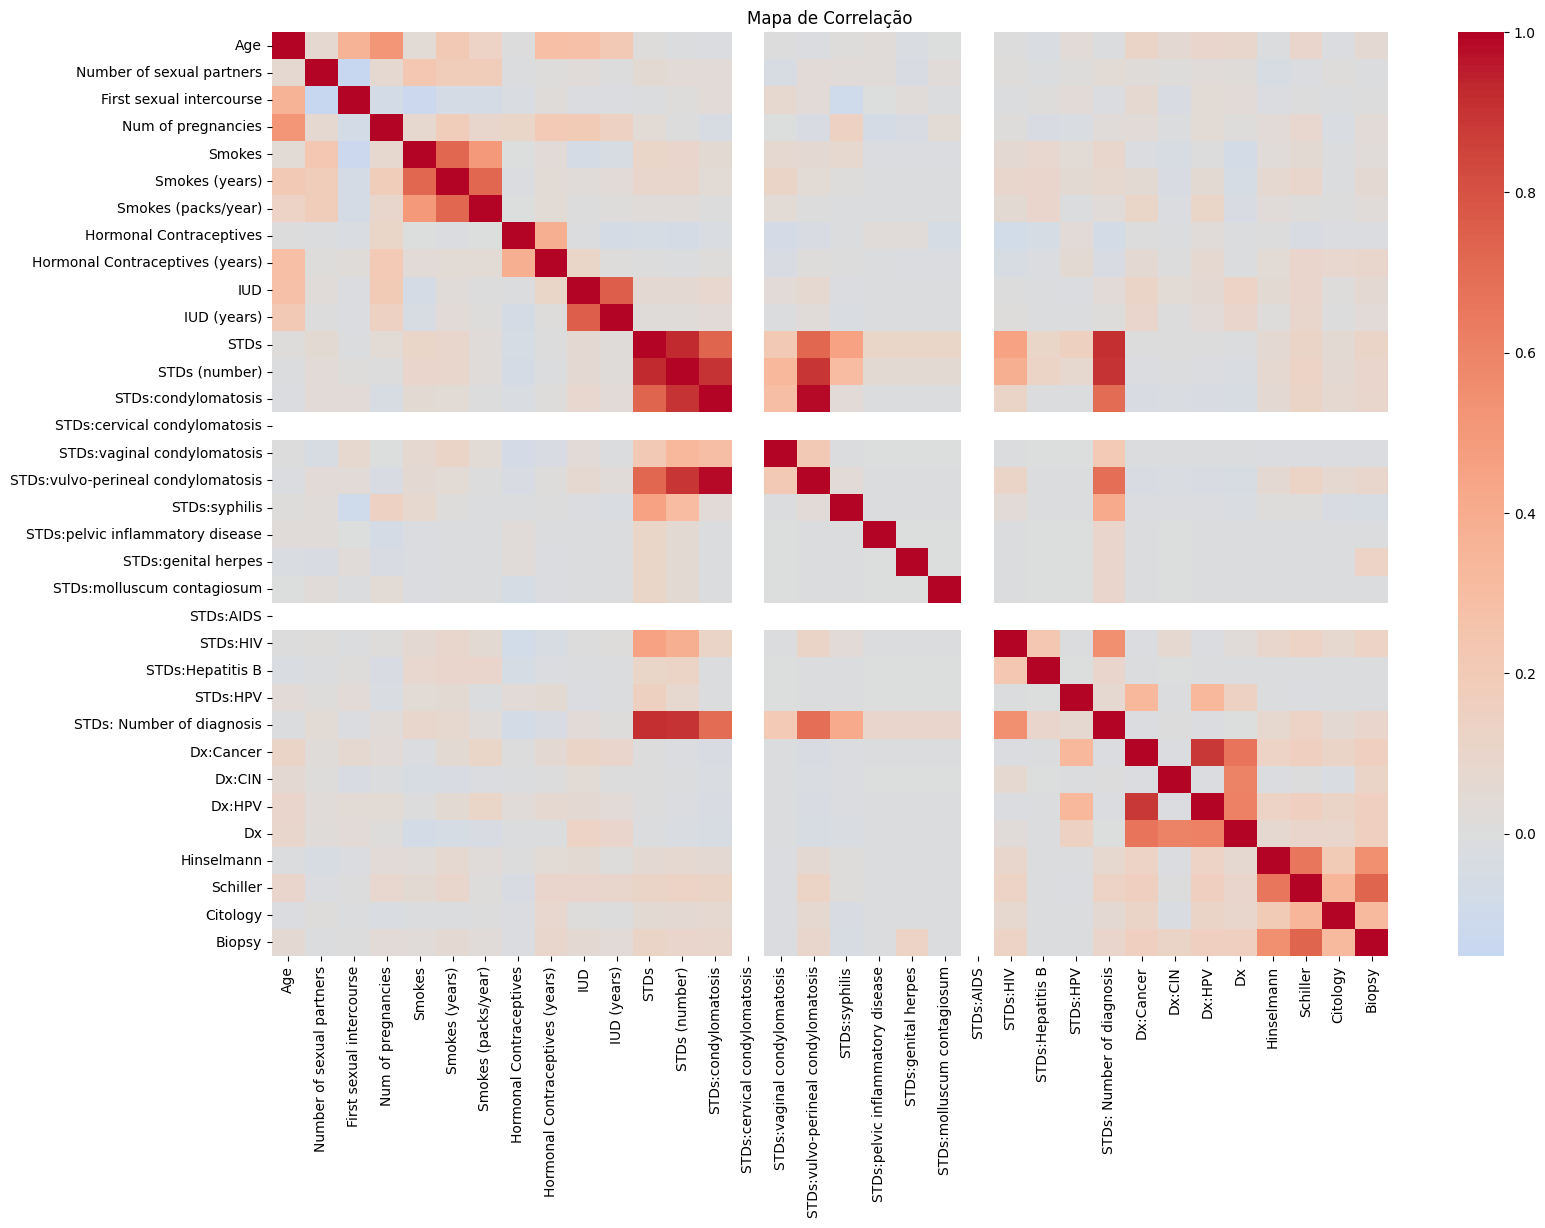

In [64]:
plt.figure(figsize=(18,12))

corr = df_imputed.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Mapa de Correlação')

plt.savefig('../images/mapa-de-correlacao.png', bbox_inches='tight')

plt.show()

#### Pergunta 9 — Quais variáveis possuem maiores médias entre pacientes positivas?

A comparação das médias ajuda a identificar quais variáveis apresentam valores mais elevados entre pacientes com diagnóstico positivo. O gráfico de barras horizontais confirma que "Age" e "First sexual intercourse" são as variáveis com os maiores valores médios absolutos no grupo de pacientes positivas.
Essa análise pode fornecer pistas importantes sobre fatores potencialmente relevantes para os modelos de Machine Learning.

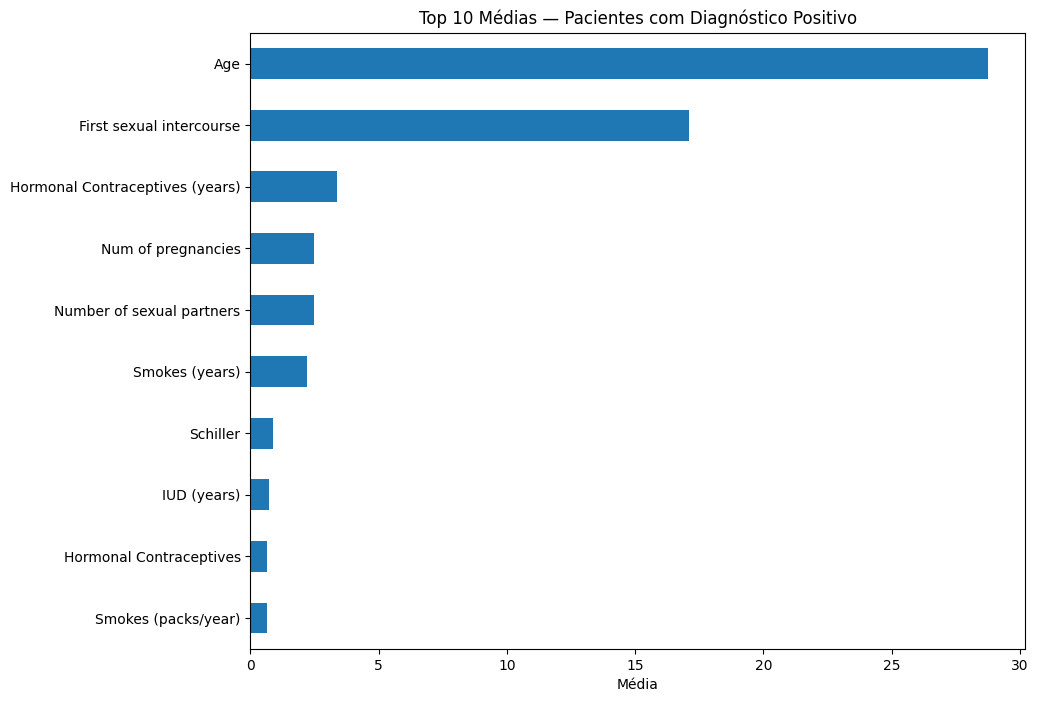

In [65]:
media_biopsy = df_imputed.groupby('Biopsy').mean().T

media_biopsy = media_biopsy.sort_values(
    by=1,
    ascending=False
)

plt.figure(figsize=(10,8))

media_biopsy[1].head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Médias — Pacientes com Diagnóstico Positivo')

plt.savefig('../images/top-10-medias.png', bbox_inches='tight')

plt.xlabel('Média')

plt.show()

#### Pergunta 10 — Como estão distribuídas as principais variáveis numéricas?

Os histogramas foram utilizados para analisar a distribuição de cada variável numérica presente no dataset. Por meio dessa visualização, foi possível observar a concentração dos valores, identificar possíveis assimetrias na distribuição, verificar a presença de outliers e analisar variáveis que podem estar muito desbalanceadas.

Essas informações são importantes para compreender melhor o comportamento dos dados antes da etapa de modelagem, auxiliando na escolha de técnicas mais adequadas para o tratamento e treinamento dos modelos.

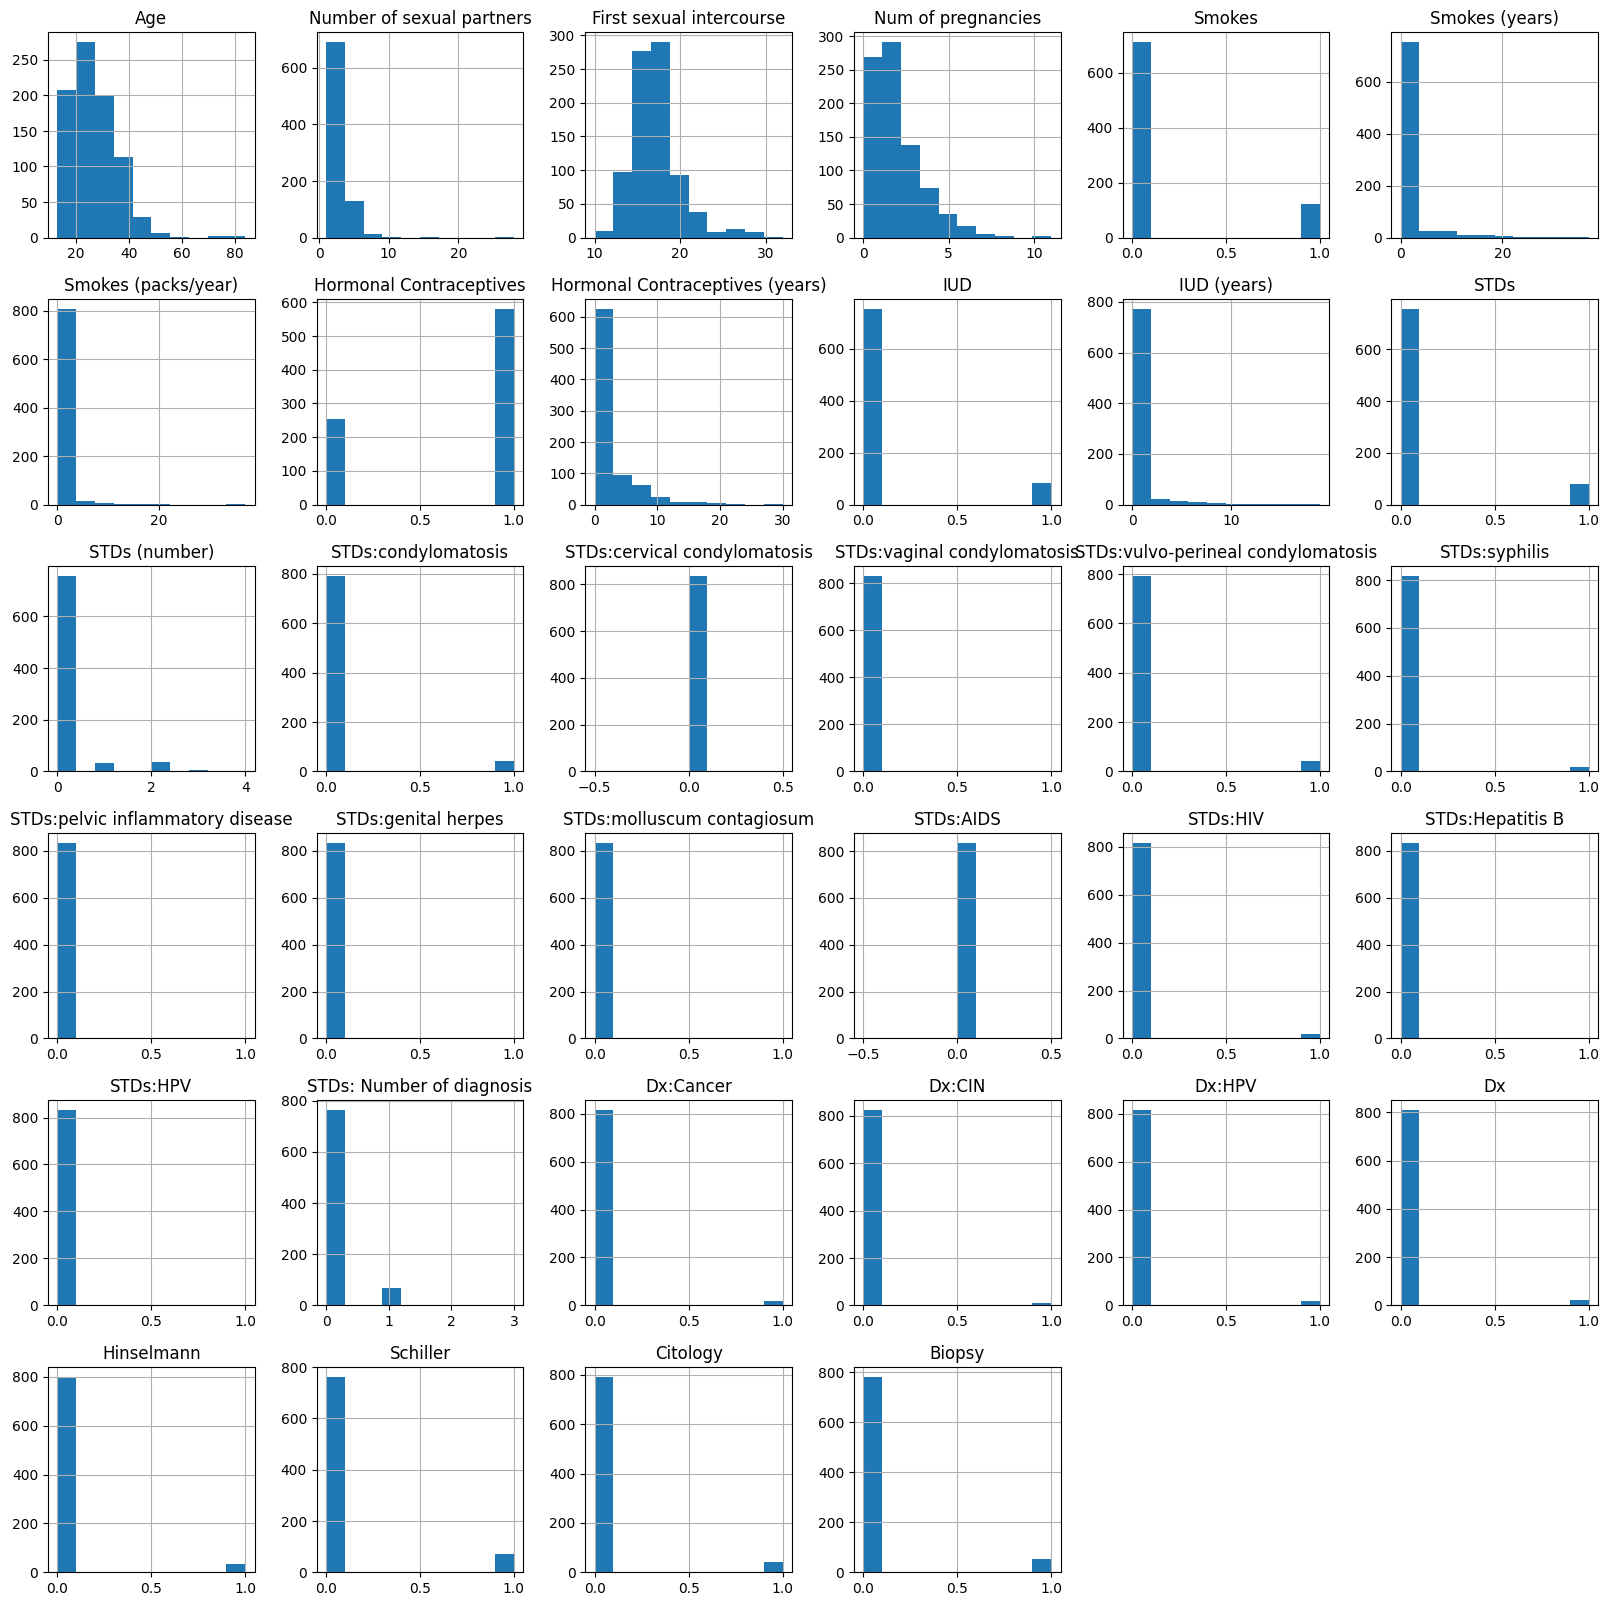

In [26]:
df_imputed.hist(figsize=(20,20))

plt.show()

# Preparação e Pré-processamento de Dados

Nesta etapa, realizei a separação das variáveis preditoras (features) e da variável alvo, responsável pelo resultado da biópsia. Em seguida, os dados foram divididos em conjuntos de treino e teste utilizando estratificação, garantindo que a proporção das classes fosse mantida em ambos os grupos.

Depois disso, apliquei o StandardScaler para padronizar as variáveis numéricas, deixando os dados na mesma escala. Essa etapa é importante porque alguns algoritmos de Machine Learning podem apresentar melhor desempenho quando as variáveis possuem valores padronizados.

#### Separação de Features e Target

In [27]:
X = df_imputed.drop('Biopsy', axis=1)

y = df_imputed['Biopsy']

#### Divisão Treino e Teste

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### Padronização

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo 1 — Regressão Logística

## Justificativa

A Regressão Logística foi escolhida por ser um dos algoritmos mais utilizados em problemas de classificação binária, como é o caso deste projeto. Além de apresentar bom desempenho em muitos cenários, ela possui uma característica importante: a interpretabilidade.

No contexto de aplicações médicas, essa interpretabilidade é fundamental, pois permite entender como cada variável influencia na previsão do modelo. Por meio dos coeficientes, é possível analisar a relação entre os fatores de risco e a probabilidade de ocorrência da doença, o que torna os resultados mais transparentes e confiáveis para análise.

Outro ponto relevante é que a Regressão Logística é um modelo mais simples quando comparado a algoritmos mais complexos, o que reduz o risco de overfitting e facilita tanto a implementação quanto a explicação dos resultados. Por isso, ela se torna uma boa escolha como modelo inicial para esse tipo de problema.

#### Treinamento do Modelo

In [31]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

#### Métricas do Modelo

In [32]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       156
         1.0       0.82      0.82      0.82        11

    accuracy                           0.98       167
   macro avg       0.90      0.90      0.90       167
weighted avg       0.98      0.98      0.98       167



#### Accuracy, Recall e F1

In [33]:
print('Accuracy:', accuracy_score(y_test, y_pred_lr))

print('Recall:', recall_score(y_test, y_pred_lr))

print('F1 Score:', f1_score(y_test, y_pred_lr))

Accuracy: 0.9760479041916168
Recall: 0.8181818181818182
F1 Score: 0.8181818181818182


#### Discussão

A Regressão Logística foi utilizada como primeiro modelo de classificação para prever o risco de diagnóstico positivo de câncer cervical com base nas variáveis disponíveis no dataset.

Esse modelo funciona estimando a probabilidade de uma paciente pertencer à classe positiva (diagnóstico presente), considerando fatores como idade, histórico clínico e comportamental. A partir dessa probabilidade, o modelo realiza a classificação final entre as classes 0 (negativo) e 1 (positivo).

Ao avaliar o desempenho do modelo, é importante analisar não apenas a acurácia, mas também métricas como recall e F1-score. Em especial, o recall possui grande relevância em aplicações na área da saúde.

Os resultados obtidos mostram que a Regressão Logística apresenta desempenho satisfatório, sendo capaz de identificar uma parcela relevante dos casos positivos, além de fornecer um modelo interpretável, característica importante em aplicações médicas.

#### Matriz de Confusão

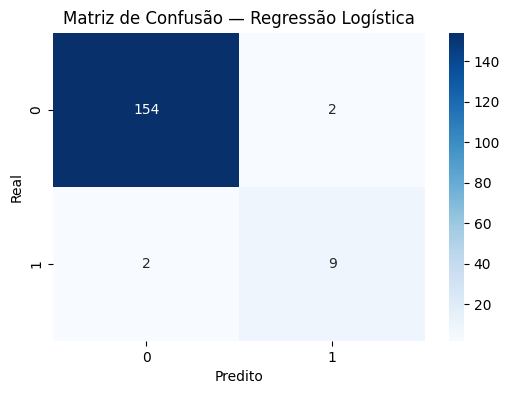

In [66]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Matriz de Confusão — Regressão Logística')

plt.savefig('../images/matriz-de-confusao-regressao-logistica.png', bbox_inches='tight')

plt.xlabel('Predito')
plt.ylabel('Real')

plt.show()

#### Discussão

A matriz de confusão é uma ferramenta fundamental para avaliar o desempenho de modelos de classificação, pois permite visualizar de forma detalhada os acertos e erros do modelo.

Ela compara os valores reais com os valores preditos, permitindo identificar quatro situações: verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos.

No contexto deste projeto, o erro mais crítico é o falso negativo, que ocorre quando o modelo classifica uma paciente como saudável, quando na realidade ela possui a condição. Esse tipo de erro pode ter consequências graves, pois pode levar à ausência de diagnóstico e atraso no tratamento.

Ao analisar a matriz de confusão do modelo de Regressão Logística, é possível observar como o modelo se comporta na identificação dos casos positivos e negativos, permitindo uma avaliação mais completa do seu desempenho.

Dessa forma, a matriz de confusão complementa métricas como acurácia, recall e F1-score, fornecendo uma visão mais detalhada da qualidade das previsões realizadas.

# Modelo 2 — Árvore de Decisão

#### Justificativa

A árvore de decisão foi um dos modelos escolhidos, pois esse tipo de modelo funciona como uma sequência de regras, facilitando o entendimento de como fatores como idade, histórico clínico e comportamental contribuem para a previsão do diagnóstico.

#### Treinamento do Modelo

In [35]:
tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

#### Métricas do Modelo

In [36]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

         0.0       0.99      0.97      0.98       156
         1.0       0.69      0.82      0.75        11

    accuracy                           0.96       167
   macro avg       0.84      0.90      0.87       167
weighted avg       0.97      0.96      0.97       167



#### Accuracy, Recall e F1

In [37]:
print('Accuracy:', accuracy_score(y_test, y_pred_tree))

print('Recall:', recall_score(y_test, y_pred_tree))

print('F1 Score:', f1_score(y_test, y_pred_tree))

Accuracy: 0.9640718562874252
Recall: 0.8181818181818182
F1 Score: 0.75


#### Matriz de Confusão

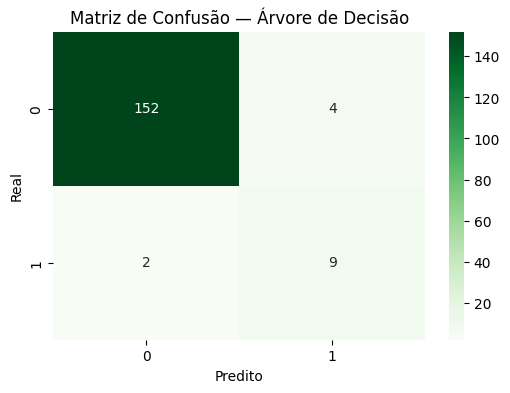

In [67]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6,4))

sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens')

plt.title('Matriz de Confusão — Árvore de Decisão')

plt.savefig('../images/matriz-de-confusao-arvore-de-decisao.png', bbox_inches='tight')

plt.xlabel('Predito')
plt.ylabel('Real')

plt.show()

#### Discussão

Durante a análise, foi possível observar que algumas variáveis exercem maior influência no diagnóstico, o que contribui não apenas para a predição, mas também para uma melhor compreensão dos possíveis fatores de risco associados ao câncer de colo do útero.
    No entanto, é importante destacar que árvores de decisão podem sofrer com overfitting, ou seja, podem se ajustar excessivamente aos dados de treino. Por isso, o controle de parâmetros como profundidade máxima da árvore é essencial para garantir um modelo mais equilibrado.

De forma geral, a Árvore de Decisão se mostrou uma boa alternativa complementar à Regressão Logística, oferecendo maior interpretabilidade e contribuindo para a análise dos fatores mais relevantes no diagnóstico.

# Comparação Entre os Modelos

Ao comparar os modelos, observa-se que a Regressão Logística apresenta maior estabilidade e interpretabilidade estatística, enquanto a Árvore de Decisão se destaca pela facilidade de visualização das regras de decisão.

Ambos os modelos apresentaram desempenho satisfatório, porém a escolha do melhor modelo depende do objetivo da aplicação, sendo que, em contextos médicos, modelos com maior capacidade de identificar casos positivos (maior recall) tendem a ser mais adequados, minimizando falsos negativos, tornando o recall uma métrica prioritária.

#### Feature Importance

In [39]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
31,Schiller,0.677029
0,Age,0.116332
2,First sexual intercourse,0.050179
8,Hormonal Contraceptives (years),0.033056
19,STDs:genital herpes,0.032440
1,Number of sexual partners,0.029364
11,STDs,0.027529
16,STDs:vulvo-perineal condylomatosis,0.016517
27,Dx:CIN,0.015654
32,Citology,0.001899


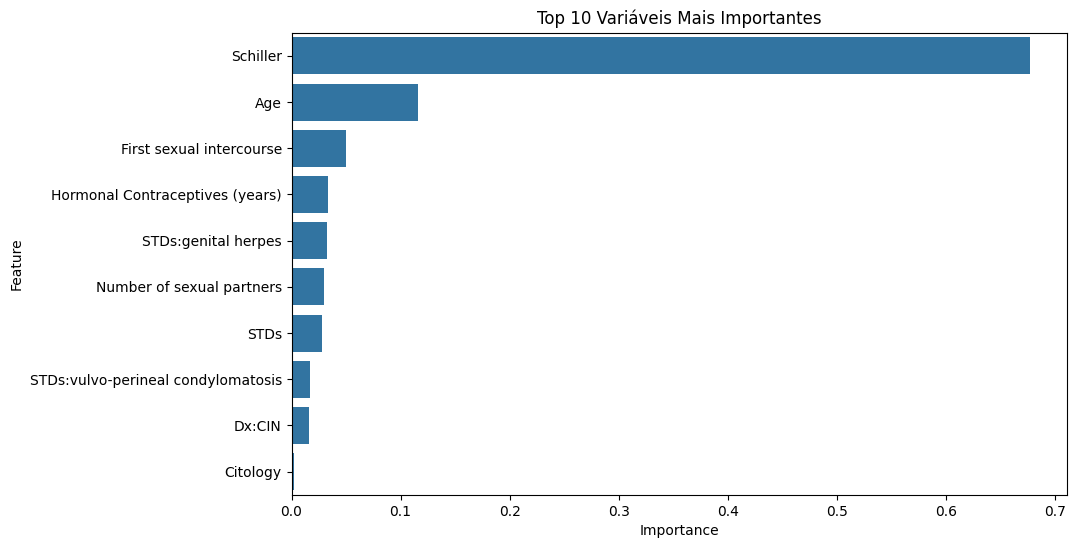

In [68]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title('Top 10 Variáveis Mais Importantes')

plt.savefig('../images/10-variaveis-mais-importantes.png', bbox_inches='tight')

plt.show()

#### Discussão

A análise de importância das variáveis permite identificar quais fatores tiveram maior influência nas decisões do modelo ao realizar as previsões. Isso é especialmente relevante neste projeto, pois ajuda a entender quais características das pacientes estão mais associadas ao diagnóstico positivo.

Ao observar as variáveis mais importantes, é possível obter insights sobre possíveis fatores de risco, como aspectos clínicos e comportamentais que aparecem com maior peso nas decisões do modelo. Essa interpretação contribui não apenas para avaliar o desempenho do modelo, mas também para enriquecer a análise exploratória realizada anteriormente.

Além disso, esse tipo de análise aumenta a transparência do modelo, tornando mais claro como as previsões estão sendo feitas. Em aplicações na área da saúde, essa interpretabilidade é fundamental, pois permite que os resultados sejam melhor compreendidos e utilizados como apoio à tomada de decisão.

No entanto, é importante destacar que a importância das variáveis indica apenas associação com o resultado previsto pelo modelo, não sendo possível afirmar relações de causa e efeito apenas com base nessa análise.

#### SHAP

In [53]:
explainer = shap.TreeExplainer(tree)

shap_values = explainer.shap_values(X_test)

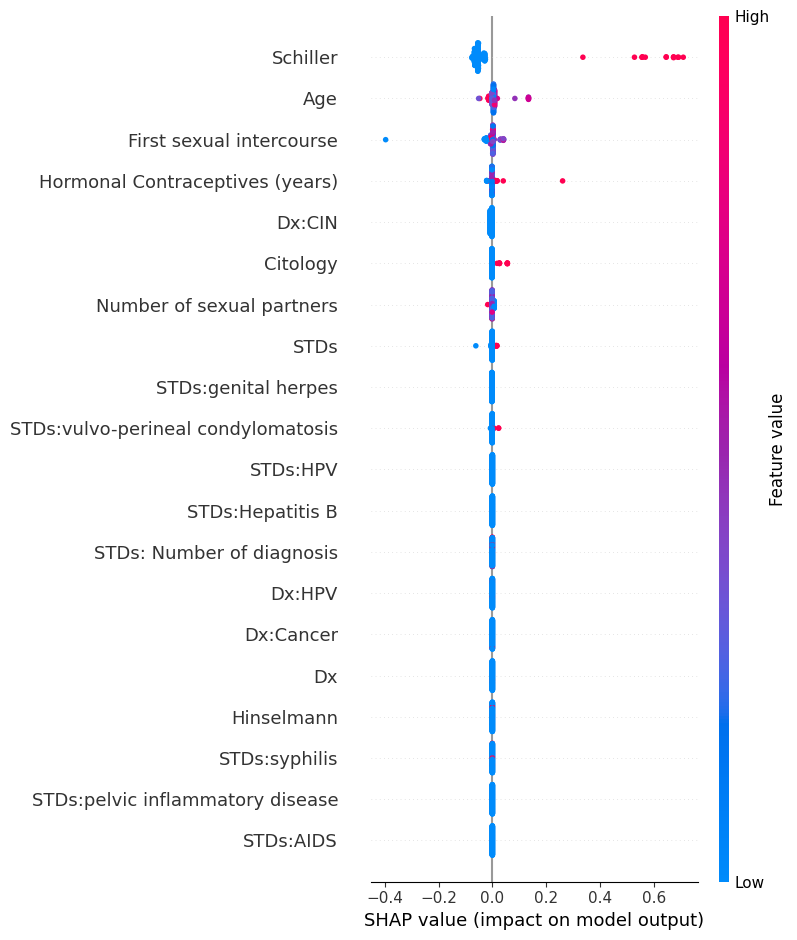

In [54]:
shap.summary_plot(shap_values[:, :, 1], X_test)

#### Discussão

Ao aplicar a técnica de explicabilidade com SHAP, observou-se que os valores retornados possuíam três dimensões, representando as amostras, as variáveis e as classes do problema.

Como se trata de um problema de classificação binária, foi necessário selecionar apenas a classe positiva (diagnóstico presente) para análise. Dessa forma, foi possível interpretar quais variáveis mais influenciam o modelo na identificação de pacientes com maior risco.

Após esse ajuste, o gráfico gerado permitiu visualizar de forma clara a importância das variáveis e seu impacto nas previsões realizadas pelo modelo.

# Conclusão

O projeto demonstrou a aplicação de técnicas de Machine Learning na análise de fatores de risco relacionados ao câncer de colo do útero.

Durante o desenvolvimento, foram realizadas etapas de tratamento de dados, análise exploratória, treinamento de modelos preditivos e interpretação dos resultados.

A análise exploratória permitiu identificar padrões relevantes entre variáveis clínicas e comportamentais associadas ao diagnóstico positivo. Além disso, os modelos de classificação apresentaram desempenho satisfatório na identificação de possíveis casos de risco.

A Regressão Logística apresentou melhor equilíbrio entre métricas de desempenho, enquanto a Árvore de Decisão forneceu maior interpretabilidade.

O uso de técnicas de explicabilidade, como Feature Importance e SHAP, contribuiu para aumentar a transparência das decisões realizadas pelos modelos.

Entretanto, é importante destacar que modelos de Inteligência Artificial não substituem profissionais médicos, devendo ser utilizados apenas como ferramentas de apoio à tomada de decisão.

Por fim, o projeto reforça o potencial da Ciência de Dados e do Machine Learning na área da saúde, especialmente em aplicações relacionadas à prevenção, identificação precoce e apoio diagnóstico.

#### Referências

- Kaggle — Cervical Cancer (Risk Factors)
- Scikit-learn Documentation
- SHAP Documentation
- Organização Mundial da Saúde (OMS)